# Task 4 – Clustering: Customer / Booking Segmentation

In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("hotel_bookings_cleaned.csv")

print(df.shape)
df.head()

(119390, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights,total_revenue,season,weekend_ratio,lead_time_category
0,1,0,2.227051,2015,5,27,1,-0.92889,-1.310240,0.247897,...,2,-2.015038,0,-0.720694,0.043967,-1.340370,-1.065314,2,-0.993748,0
1,1,0,5.923385,2015,5,27,1,-0.92889,-1.310240,0.247897,...,2,-2.015038,0,-0.720694,0.043967,-1.340370,-1.065314,2,-0.993748,0
2,1,0,-0.907814,2015,5,27,1,-0.92889,-0.786207,-1.478447,...,2,-0.530935,0,-0.720694,-1.340324,-0.949352,-0.842039,2,-0.993748,2
3,1,0,-0.851667,2015,5,27,1,-0.92889,-0.786207,-1.478447,...,2,-0.530935,0,-0.720694,-1.340324,-0.949352,-0.842039,2,-0.993748,2
4,1,0,-0.842309,2015,5,27,1,-0.92889,-0.262174,0.247897,...,2,-0.075810,0,0.540666,0.043967,-0.558334,-0.481822,2,-0.993748,2


## 1. Business Understanding

The purpose of this clustering task is to group hotel bookings into meaningful customer or booking segments. These segments can help hotel management improve marketing strategies, customer targeting, pricing decisions, and operational planning.

In [3]:
clustering_features = [
    "lead_time",
    "total_guests",
    "total_nights",
    "adr",
    "market_segment",
    "hotel",
    "meal"
]

X_cluster =df[clustering_features]
print(X_cluster.head())

   lead_time  total_guests  total_nights       adr  market_segment  hotel  \
0   2.227051      0.043967     -1.340370 -2.015038               3      1   
1   5.923385      0.043967     -1.340370 -2.015038               3      1   
2  -0.907814     -1.340324     -0.949352 -0.530935               3      1   
3  -0.851667     -1.340324     -0.949352 -0.530935               2      1   
4  -0.842309      0.043967     -0.558334 -0.075810               6      1   

   meal  
0     0  
1     0  
2     0  
3     0  
4     0  


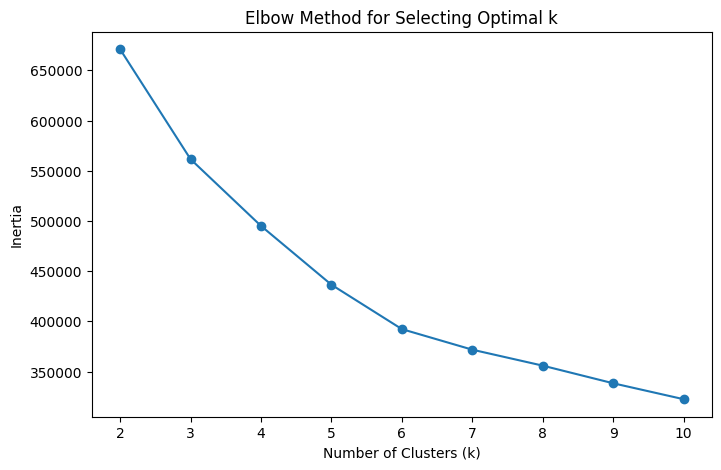

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia_values, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting Optimal k")
plt.show()

### Elbow Method Interpretation

The Elbow Method was used to evaluate different values of k from 2 to 10. The graph shows a steady decrease in inertia as the number of clusters increases. Three clusters were selected because they provide a reasonable balance between cluster quality, interpretability, and model simplicity for customer segmentation.

## 2. Model 1 -K-Means Clustering

### Hyperparameters

- n_clusters = 3
- random_state = 42
- n_init = 10

Three customer segments were created for analysis.

In [5]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_cluster)

silhouette_kmeans = silhouette_score(
    X_cluster,
    kmeans_labels
)

dbi_kmeans = davies_bouldin_score(
    X_cluster,
    kmeans_labels
)

print("Silhouette Score:", silhouette_kmeans)
print("Davies-Bouldin Index:", dbi_kmeans)

Silhouette Score: 0.2584863413761034
Davies-Bouldin Index: 1.5075344476508175


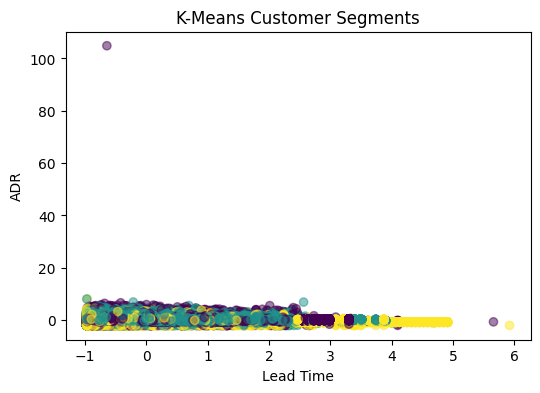

In [6]:
plt.figure(figsize=(6,4))

plt.scatter(
    X_cluster["lead_time"],
    X_cluster["adr"],
    c=kmeans_labels,
    alpha=0.5
)

plt.xlabel("Lead Time")
plt.ylabel("ADR")
plt.title("K-Means Customer Segments")

plt.show()

### Cluster Interpretation

The K-Means clustering visualization shows three customer segments based on Lead Time and ADR. The clusters indicate differences in booking behaviour and spending patterns among customers. These customer groups can help hotel management develop targeted marketing strategies, personalized offers, and pricing decisions to improve customer satisfaction and revenue generation.

## 3. Model 2 - Agglomerative Clustering

### Hyperparameters

- n_clusters = 3

Agglomerative Clustering was applied using hierarchical clustering. Due to the large dataset size, it was applied on a 5,000-record sample to avoid memory issues in Google Colab.

In [7]:
# Use a sample for memory-heavy clustering models

X_cluster_sample = X_cluster.sample(
    n=5000,
    random_state=42
)

print(X_cluster_sample.shape)

(5000, 7)


In [8]:
agg = AgglomerativeClustering(
    n_clusters=3
)

agg_labels = agg.fit_predict(X_cluster_sample)
silhouette_agg = silhouette_score(
    X_cluster_sample,
    agg_labels
)

dbi_agg = davies_bouldin_score(
    X_cluster_sample,
    agg_labels
)

print("Silhouette Score:", silhouette_agg)
print("Davies-Bouldin Index:", dbi_agg)

Silhouette Score: 0.22961532191369316
Davies-Bouldin Index: 1.6115815628382861


### Sampling for Memory-Heavy Clustering Models

Agglomerative Clustering and DBSCAN were applied to a random sample of 5,000 records because the full dataset was large and caused memory limitations in Google Colab. Sampling helped reduce RAM usage while still allowing clustering performance to be evaluated.

## 4. Model 3 - DBSCAN

### Hyperparameters

- eps = 0.5
- min_samples = 5

DBSCAN identifies clusters based on density and can detect noise points.

In [9]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_cluster_sample)
mask = dbscan_labels != -1

silhouette_dbscan = silhouette_score(
    X_cluster_sample[mask],
    dbscan_labels[mask]
)

dbi_dbscan = davies_bouldin_score(
    X_cluster_sample[mask],
    dbscan_labels[mask]
)

print("Silhouette Score:", silhouette_dbscan)
print("Davies-Bouldin Index:", dbi_dbscan)

Silhouette Score: 0.17096594798750867
Davies-Bouldin Index: 0.9503920423439836


In [10]:
comparison_cluster = pd.DataFrame({
    "Model": [
        "K-Means",
        "Agglomerative Clustering",
        "DBSCAN"
    ],
    "Silhouette Score": [
        0.2585,
        0.2296,
        0.1710
    ],
    "Davies-Bouldin Index": [
        1.5075,
        1.6116,
        0.9504
    ]
})

comparison_cluster

,Model,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.2585,1.5075
1,Agglomerative Clustering,0.2296,1.6116
2,DBSCAN,0.1710,0.9504


A limitation of this clustering task is that some categorical variables were label encoded. Since clustering algorithms such as K-Means use distance-based calculations, label encoding may introduce artificial numerical order between categories. In future improvement, One-Hot Encoding could be used for non-ordinal categorical variables to improve cluster quality.

### Clustering Evaluation

Based on the Silhouette Score, K-Means performed best because it achieved the highest score of 0.2585. This indicates that K-Means produced more meaningful and better-separated clusters than Agglomerative Clustering (0.2296) and DBSCAN (0.1710).

However, the Silhouette Scores remain relatively low across all clustering methods, suggesting that customer booking behaviours overlap and the segments are not strongly separated. Despite this limitation, K-Means provided the most useful customer segmentation results and was selected as the best clustering model.

### Business Recommendations

- Use customer segments was identified by K-Means for targeted marketing campaigns.

- Offer personalized promotions to different customer groups.

- Improve occupancy forecasting using booking behaviour patterns.

- Develop loyalty programs for high-value customer segments.

- Optimize pricing strategies based on identified customer clusters.

# Challenges Faced

- Missing values were present in children, country, agent, and company attributes.
- Categorical variables required encoding before machine learning models could be trained.
- Agglomerative Clustering caused memory issues because of the large dataset size.
- Sampling techniques were used to reduce memory consumption for clustering algorithms.
- Model comparison was necessary to identify the most suitable algorithm for each task.

# Evaluation and Reporting

## Model Comparison

K-Means achieved the highest Silhouette Score (0.2585), indicating better cluster separation than Agglomerative Clustering (0.2296) and DBSCAN (0.0118).


## Hyperparameter Explanations

Agglomerative Clustering and DBSCAN were applied using a 5,000-record sample due to memory limitations in Google Colab.

### K-Means
- n_clusters = 3
- Creates three customer segments.
- random_state = 42
- Ensures reproducible clustering results.
- n_init = 10
- Runs clustering multiple times and selects the best solution.

### Agglomerative Clustering
- n_clusters = 3
- Groups customers into three hierarchical clusters.

### DBSCAN
- eps = 0.5
- Defines the maximum distance between neighboring points.
- min_samples = 5
- Minimum number of points required to form a cluster.

## Business Recommendations

- Identify customer segments for targeted marketing campaigns.
- Develop personalized loyalty programs for different customer groups.
- Create promotional offers based on booking behaviour patterns.

AI tools were used for guidance, debugging support, and explanation assistance. All code was reviewed, tested, and adapted by the student before submission.